# Ridge Regression - Walk-Forward Validation

This notebook implements **Ridge Regression** with walk-forward validation for 24-hour ahead price forecasting.

## Approach
- **Model**: Ridge Regression (L2 regularization)
- **Validation**: Walk-forward with daily retraining
- **No Data Leakage**: Only use data available at prediction time
- **Production-ready**: Simulates real trading conditions

## Workflow
1. Load dataset with forecast features
2. Split: Initial training period (1 year) + walk-forward test
3. Each day:
   - Train on all historical data
   - Predict next 24 hours
   - Evaluate predictions
4. Calculate comprehensive metrics
5. Visualize results

In [1]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.insert(0, str(project_root))

from model.price_forecasting.walk_forward_validator import (
    walk_forward_validate,
    plot_walk_forward_results,
    save_walk_forward_results
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("✅ Imports successful")

✅ Imports successful


## 1. Load Dataset with Forecast Features

In [2]:
# Load the unified dataset with all forecast features
data_path = project_root / "data/processed/price_forecasting_dataset_with_forecasts.csv"

df = pd.read_csv(data_path)
df['datetime_hour'] = pd.to_datetime(df['datetime_hour'])

print(f"Dataset loaded: {len(df):,} rows × {len(df.columns)} columns")
print(f"Date range: {df['datetime_hour'].min()} to {df['datetime_hour'].max()}")
print(f"\nColumns: {list(df.columns)}")

df.head()

Dataset loaded: 17,124 rows × 63 columns
Date range: 2023-01-09 04:00:00 to 2024-12-30 23:00:00

Columns: ['datetime_hour', 'price', 'load_actual', 'temp_actual', 'humidity_actual', 'precipitation_actual', 'wind10m_actual', 'wind100m_actual', 'solar_radiation_actual', 'cloudcover_actual', 'temp_forecast', 'wind10m_forecast', 'wind100m_forecast', 'solar_radiation_forecast', 'humidity_forecast', 'precipitation_forecast', 'cloudcover_forecast', 'load_forecast', 'wind_production_forecast_mw', 'solar_production_forecast_mw', 'renewable_production_forecast_mw', 'renewable_penetration_pct', 'net_load_forecast_mw', 'renewable_curtailment_mw', 'renewable_coverage_pct', 'wind_capacity_factor', 'solar_capacity_factor', 'residual_load_intensity', 'hour', 'day_of_week', 'day_of_month', 'day_of_year', 'week_of_year', 'month', 'quarter', 'year', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'is_peak_hour', 'is_night', 'is_winter', 'is_summer', 'price_lag_24h', 

,datetime_hour,price,load_actual,temp_actual,humidity_actual,precipitation_actual,wind10m_actual,wind100m_actual,solar_radiation_actual,cloudcover_actual,...,load_actual_lag_72h,load_actual_lag_168h,price_roll_mean_24h,price_roll_std_24h,price_roll_mean_168h,price_roll_std_168h,load_actual_roll_mean_24h,load_actual_roll_std_24h,load_actual_roll_mean_168h,load_actual_roll_std_168h
0,2023-01-09 04:00:00,43.99,48980.0,4.1,86,0.0,16.3,31.6,0.0,100,...,46641.0,39070.0,71.689583,33.348179,102.640238,51.681903,50336.583333,3253.258486,52106.875000,6152.152051
1,2023-01-09 05:00:00,85.26,54574.0,4.2,87,0.0,16.2,31.4,0.0,100,...,45825.0,38453.0,69.030000,35.587712,102.704107,51.560664,50333.750000,3258.789362,52097.952381,6162.564818
2,2023-01-09 06:00:00,160.32,60202.0,4.6,86,0.0,15.3,29.8,0.0,100,...,47788.0,40294.0,67.002500,37.170492,102.810060,51.363515,50328.083333,3268.771767,52098.625000,6161.752051
3,2023-01-09 07:00:00,180.00,63151.0,4.8,85,0.0,15.9,29.8,0.0,100,...,52492.0,43926.0,66.139583,37.295668,103.138155,50.850123,50321.458333,3277.172402,52126.809524,6123.846955
4,2023-01-09 08:00:00,177.27,63546.0,5.3,83,0.0,17.1,30.5,0.0,100,...,57665.0,47341.0,65.887083,37.151791,103.658810,50.188416,50327.166667,3273.853980,52182.285714,6048.226893


## 2. Load Feature List (Excluding Target and Metadata)

In [3]:
# Load pre-defined feature columns (no data leakage)
features_path = project_root / "data/processed/price_forecasting_dataset_with_forecasts_features.txt"

with open(features_path, 'r') as f:
    feature_cols = [line.strip() for line in f.readlines()]

print(f"Number of features: {len(feature_cols)}")
print(f"\nFeature categories:")
print(f"  - Weather forecasts: {len([c for c in feature_cols if 'forecast' in c and any(x in c for x in ['temp', 'wind', 'solar', 'humidity'])])}")
print(f"  - Load forecast: {len([c for c in feature_cols if 'load_forecast' in c])}")
print(f"  - Renewable forecasts: {len([c for c in feature_cols if any(x in c for x in ['renewable', 'net_load', 'wind_production', 'solar_production'])])}")
print(f"  - Historical lags: {len([c for c in feature_cols if 'lag' in c])}")
print(f"  - Rolling statistics: {len([c for c in feature_cols if 'roll' in c])}")
print(f"  - Calendar features: {len([c for c in feature_cols if any(x in c for x in ['hour', 'day', 'month', 'week', 'weekend', 'peak', 'winter', 'summer', 'sin', 'cos'])])}")

print(f"\nFirst 10 features:")
for i, feat in enumerate(feature_cols[:10], 1):
    print(f"  {i:2d}. {feat}")

Number of features: 53

Feature categories:
  - Weather forecasts: 7
  - Load forecast: 2
  - Renewable forecasts: 7
  - Historical lags: 8
  - Rolling statistics: 8
  - Calendar features: 16

First 10 features:
   1. temp_forecast
   2. wind10m_forecast
   3. wind100m_forecast
   4. solar_radiation_forecast
   5. humidity_forecast
   6. precipitation_forecast
   7. cloudcover_forecast
   8. load_forecast
   9. wind_production_forecast_mw
  10. solar_production_forecast_mw


## 3. Create Ridge Regression Model with Preprocessing

Ridge regression requires feature scaling for optimal performance.

In [4]:
from sklearn.pipeline import Pipeline

# Create Ridge model with preprocessing pipeline
ridge_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Standardize features
    ('ridge', Ridge(
        alpha=1.0,  # Regularization strength
        fit_intercept=True,
        max_iter=1000,
        random_state=42
    ))
])

print("✅ Ridge Regression pipeline created")
print(f"\nModel configuration:")
print(f"  - Regularization (alpha): 1.0")
print(f"  - Solver: Automatic (cholesky/lsqr/sag)")
print(f"  - Feature scaling: StandardScaler")
print(f"\nRidge Regression characteristics:")
print(f"  ✅ Fast training and prediction")
print(f"  ✅ Good baseline model")
print(f"  ✅ Handles multicollinearity well")
print(f"  ✅ L2 regularization prevents overfitting")
print(f"  ⚠️  Assumes linear relationships")

✅ Ridge Regression pipeline created

Model configuration:
  - Regularization (alpha): 1.0
  - Solver: Automatic (cholesky/lsqr/sag)
  - Feature scaling: StandardScaler

Ridge Regression characteristics:
  ✅ Fast training and prediction
  ✅ Good baseline model
  ✅ Handles multicollinearity well
  ✅ L2 regularization prevents overfitting
  ⚠️  Assumes linear relationships


## 4. Walk-Forward Validation

This simulates real trading conditions:
- Train on 1 year of historical data initially
- Each day: retrain with new data, predict next 24 hours
- Expanding window (use all past data)
- **NO DATA LEAKAGE**: Only use features available at prediction time

In [5]:
# Walk-forward validation parameters
INITIAL_TRAIN_DAYS = 365  # 1 year of initial training data
FORECAST_HORIZON_HOURS = 24  # Predict 24 hours ahead
RETRAIN_FREQUENCY_DAYS = 1  # Retrain every day (realistic for trading)

print("Starting walk-forward validation...")
print(f"This may take a few minutes as we retrain the model daily.\n")

predictions_df, metrics, daily_metrics = walk_forward_validate(
    df=df,
    model=ridge_pipeline,
    feature_cols=feature_cols,
    target_col='price',
    initial_train_days=INITIAL_TRAIN_DAYS,
    forecast_horizon_hours=FORECAST_HORIZON_HOURS,
    retrain_frequency_days=RETRAIN_FREQUENCY_DAYS,
    expanding_window=True,  # Use all past data
    verbose=True
)

print("\n✅ Walk-forward validation completed!")

Starting walk-forward validation...
This may take a few minutes as we retrain the model daily.


✅ Walk-forward validation completed!


## 5. Overall Metrics

In [6]:
print("="*80)
print("RIDGE REGRESSION - OVERALL METRICS")
print("="*80)

print(f"\n📊 Prediction Statistics:")
print(f"  Total predictions: {metrics['n_predictions']:,} hours")
print(f"  Test period: {predictions_df['datetime_hour'].min()} to {predictions_df['datetime_hour'].max()}")
print(f"  Duration: {metrics['coverage_hours']:.0f} hours ({metrics['coverage_hours']/24:.1f} days)")

print(f"\n🎯 Accuracy Metrics:")
print(f"  MAE (Mean Absolute Error):     {metrics['mae']:8.2f} EUR/MWh")
print(f"  RMSE (Root Mean Squared Error): {metrics['rmse']:8.2f} EUR/MWh")
print(f"  MAPE (Mean Absolute % Error):   {metrics['mape']:8.2f}%")
print(f"  R² Score:                       {metrics['r2']:8.3f}")

print(f"\n📈 Directional Accuracy:")
print(f"  Direction accuracy: {metrics['direction_accuracy']:.2f}%")
print(f"  (Did we predict price increase/decrease correctly?)")

print(f"\n⚖️  Bias Analysis:")
print(f"  Bias (systematic error):  {metrics['bias']:8.2f} EUR/MWh")
print(f"  Error std deviation:      {metrics['error_std']:8.2f} EUR/MWh")

print(f"\n📉 Error Distribution:")
print(f"  5th percentile (underpredict): {metrics['error_q05']:8.2f} EUR/MWh")
print(f"  95th percentile (overpredict): {metrics['error_q95']:8.2f} EUR/MWh")
print(f"  Max overprediction:            {metrics['max_overpredict']:8.2f} EUR/MWh")
print(f"  Max underprediction:           {metrics['max_underpredict']:8.2f} EUR/MWh")

# Create metrics DataFrame for easy viewing
metrics_df = pd.DataFrame([metrics]).T
metrics_df.columns = ['Value']
metrics_df

RIDGE REGRESSION - OVERALL METRICS

📊 Prediction Statistics:
  Total predictions: 7,032 hours
  Test period: 2024-01-14 00:00:00 to 2024-12-30 23:00:00
  Duration: 8447 hours (352.0 days)

🎯 Accuracy Metrics:
  MAE (Mean Absolute Error):        18.74 EUR/MWh
  RMSE (Root Mean Squared Error):    24.69 EUR/MWh
  MAPE (Mean Absolute % Error):        inf%
  R² Score:                          0.602

📈 Directional Accuracy:
  Direction accuracy: 73.42%
  (Did we predict price increase/decrease correctly?)

⚖️  Bias Analysis:
  Bias (systematic error):     -4.38 EUR/MWh
  Error std deviation:         24.30 EUR/MWh

📉 Error Distribution:
  5th percentile (underpredict):   -42.32 EUR/MWh
  95th percentile (overpredict):    33.75 EUR/MWh
  Max overprediction:              100.13 EUR/MWh
  Max underprediction:            -132.54 EUR/MWh


,Value
mae,18.743349
rmse,24.690617
mape,inf
r2,0.602460
direction_accuracy,73.417722
bias,-4.382954
error_std,24.298483
error_q05,-42.323886
error_q95,33.750315
max_overpredict,100.127961


## 6. Visualize Results

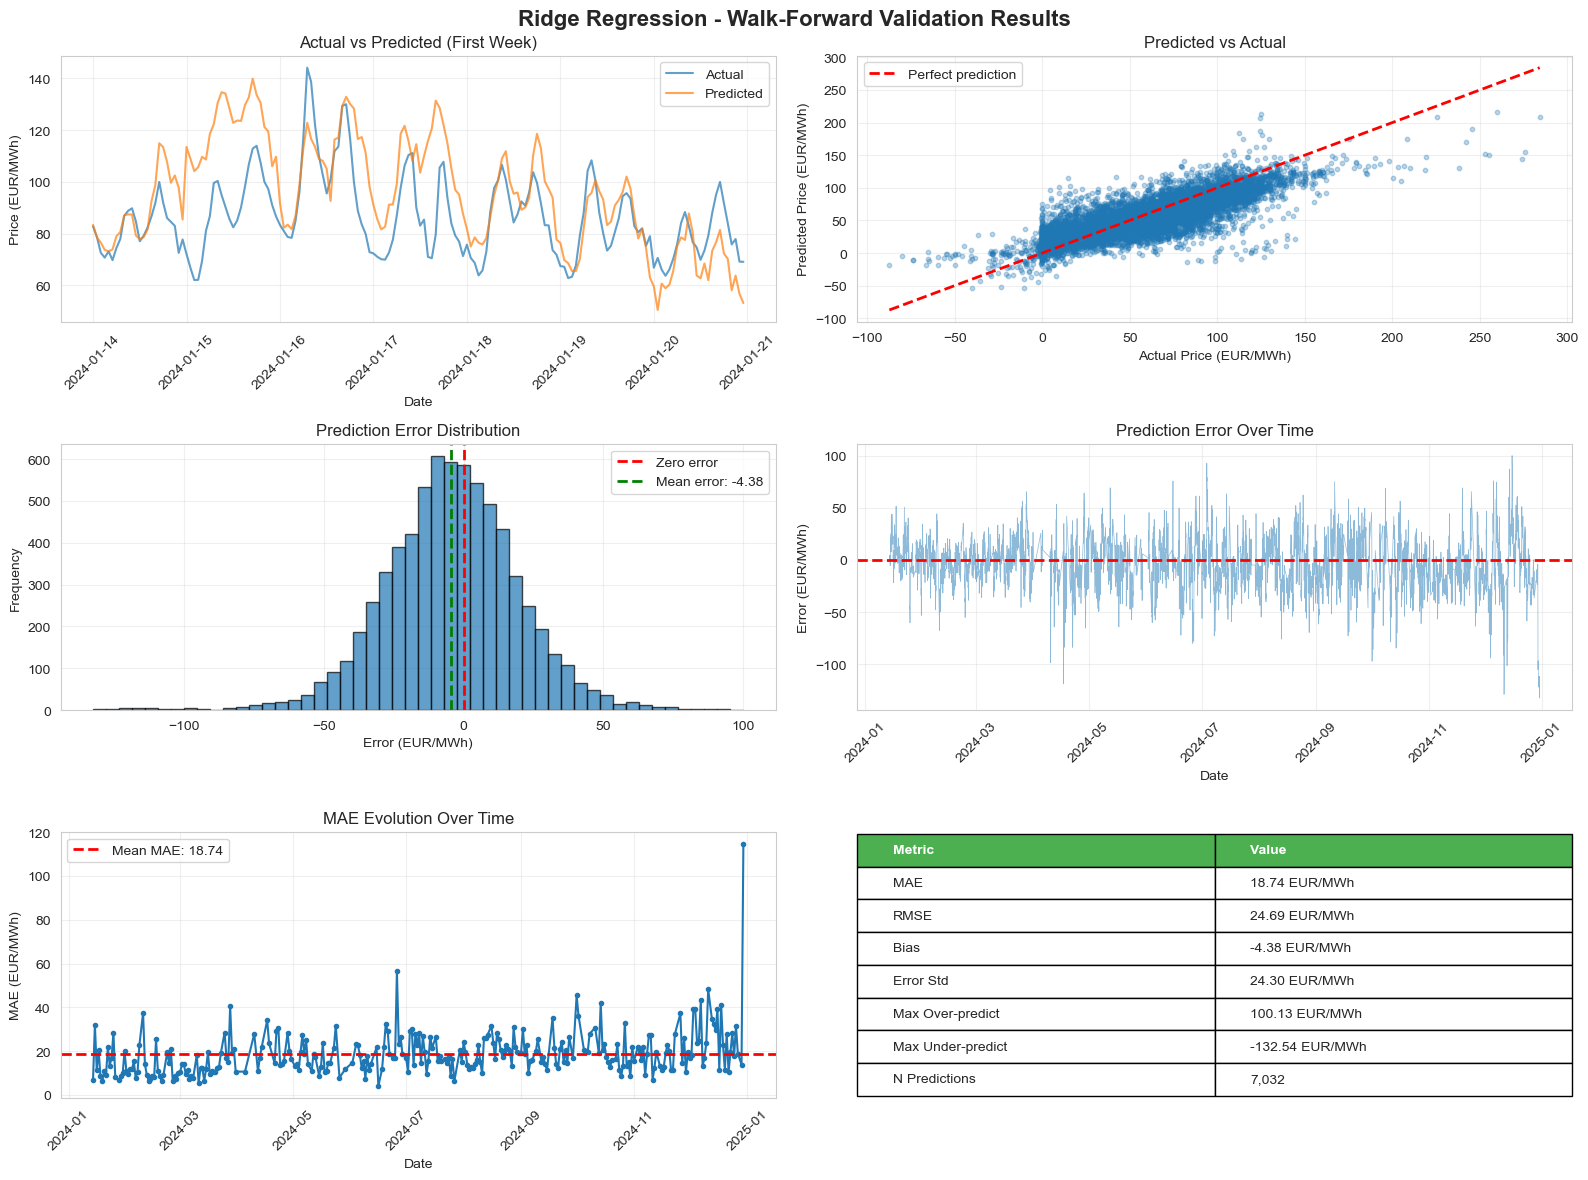


✅ Figure saved to: c:\Users\arnov\Desktop\energy-demand-forecast\research\reports\ridge_walk_forward_results.png


In [7]:
# Generate comprehensive plots
fig = plot_walk_forward_results(
    predictions_df=predictions_df,
    daily_metrics=daily_metrics,
    model_name="Ridge Regression"
)

plt.show()

# Save figure
output_dir = project_root / "research/reports"
output_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(output_dir / "ridge_walk_forward_results.png", dpi=150, bbox_inches='tight')
print(f"\n✅ Figure saved to: {output_dir / 'ridge_walk_forward_results.png'}")

## 7. Analyze Predictions by Hour of Day

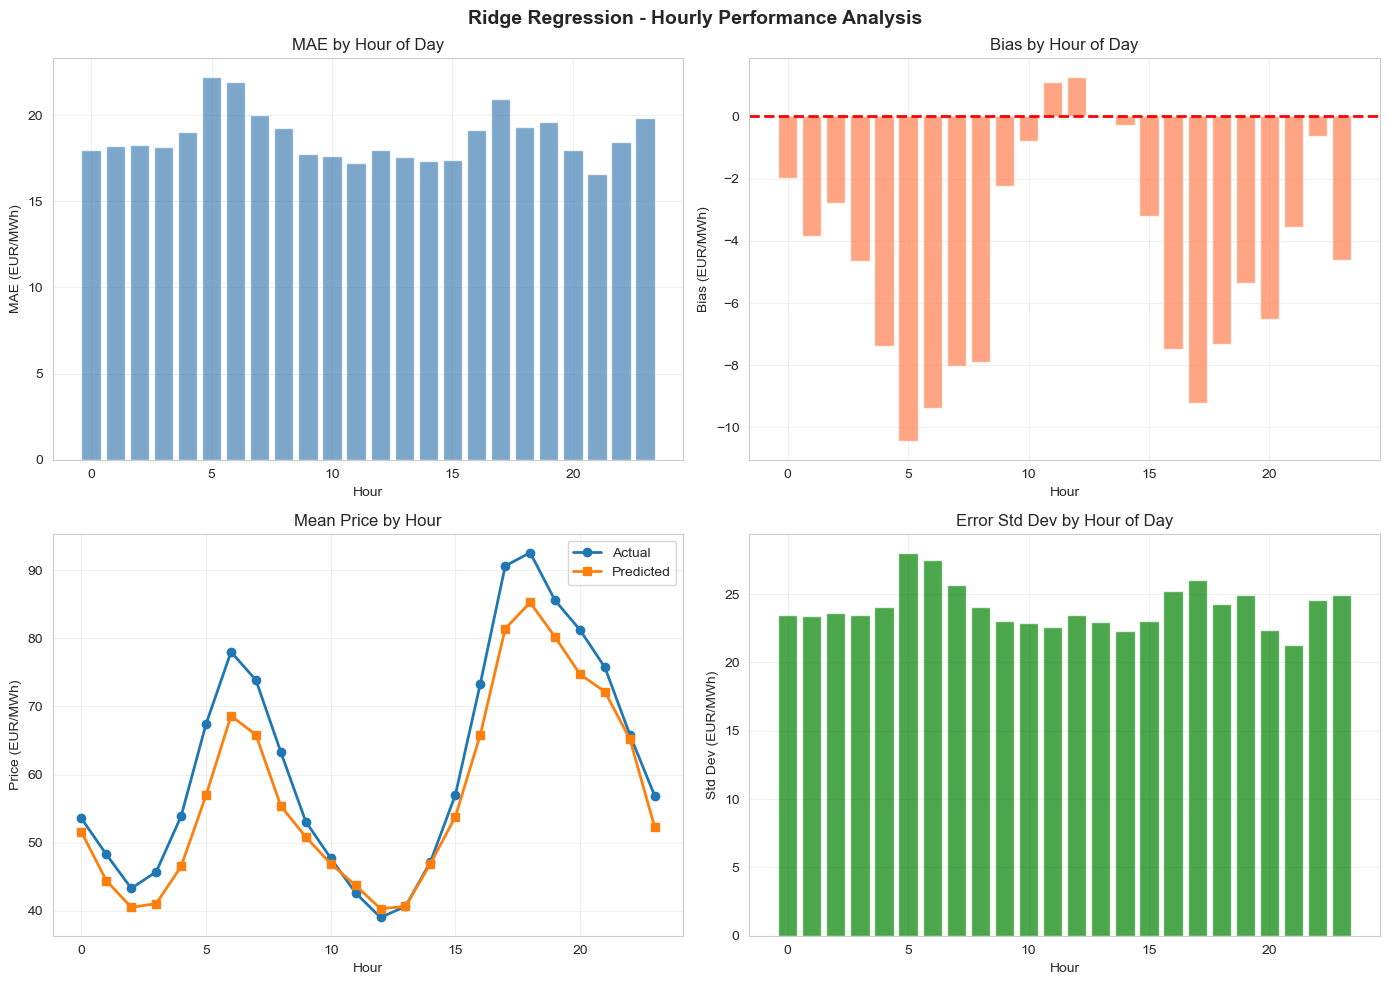


📊 Hourly Metrics Summary:
        MAE   Bias  Error_Std  Actual_Mean  Predicted_Mean
hour                                                      
0     17.99  -1.99      23.50        53.56           51.57
1     18.22  -3.84      23.43        48.28           44.44
2     18.29  -2.78      23.61        43.31           40.53
3     18.16  -4.66      23.48        45.74           41.07
4     19.04  -7.37      24.07        53.91           46.54
5     22.19 -10.45      27.97        67.43           56.99
6     21.90  -9.38      27.46        77.99           68.61
7     20.03  -8.02      25.63        73.85           65.83
8     19.25  -7.91      24.03        63.28           55.38
9     17.74  -2.25      23.01        53.09           50.84
10    17.65  -0.80      22.89        47.74           46.94
11    17.20   1.10      22.58        42.63           43.73
12    17.96   1.28      23.44        39.04           40.32
13    17.60  -0.01      22.97        40.67           40.66
14    17.34  -0.27      22.30

In [8]:
# Add hour to predictions
predictions_df['hour'] = pd.to_datetime(predictions_df['datetime_hour']).dt.hour

# Calculate metrics by hour
hourly_metrics = predictions_df.groupby('hour').agg({
    'abs_error': 'mean',
    'error': ['mean', 'std'],
    'actual': 'mean',
    'predicted': 'mean'
}).round(2)

hourly_metrics.columns = ['MAE', 'Bias', 'Error_Std', 'Actual_Mean', 'Predicted_Mean']

# Plot
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ridge Regression - Hourly Performance Analysis', fontsize=14, fontweight='bold')

# MAE by hour
axes[0, 0].bar(hourly_metrics.index, hourly_metrics['MAE'], color='steelblue', alpha=0.7)
axes[0, 0].set_title('MAE by Hour of Day')
axes[0, 0].set_xlabel('Hour')
axes[0, 0].set_ylabel('MAE (EUR/MWh)')
axes[0, 0].grid(True, alpha=0.3)

# Bias by hour
axes[0, 1].bar(hourly_metrics.index, hourly_metrics['Bias'], color='coral', alpha=0.7)
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0, 1].set_title('Bias by Hour of Day')
axes[0, 1].set_xlabel('Hour')
axes[0, 1].set_ylabel('Bias (EUR/MWh)')
axes[0, 1].grid(True, alpha=0.3)

# Actual vs Predicted mean by hour
axes[1, 0].plot(hourly_metrics.index, hourly_metrics['Actual_Mean'], marker='o', label='Actual', linewidth=2)
axes[1, 0].plot(hourly_metrics.index, hourly_metrics['Predicted_Mean'], marker='s', label='Predicted', linewidth=2)
axes[1, 0].set_title('Mean Price by Hour')
axes[1, 0].set_xlabel('Hour')
axes[1, 0].set_ylabel('Price (EUR/MWh)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Error std by hour
axes[1, 1].bar(hourly_metrics.index, hourly_metrics['Error_Std'], color='green', alpha=0.7)
axes[1, 1].set_title('Error Std Dev by Hour of Day')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Std Dev (EUR/MWh)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Hourly Metrics Summary:")
print(hourly_metrics)

## 8. Daily Metrics Evolution

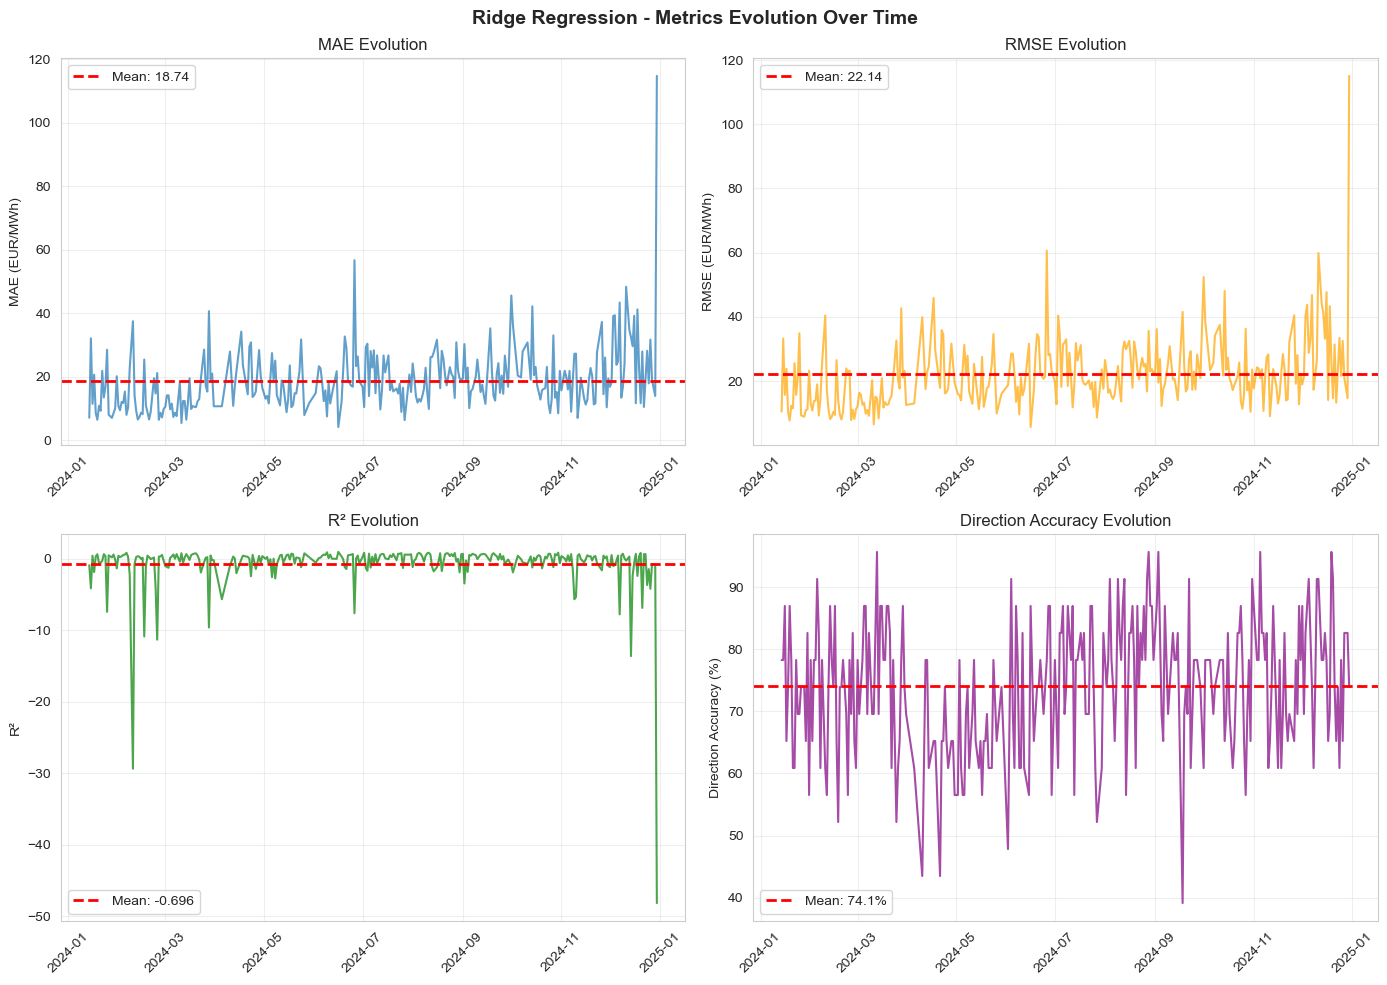


📈 Daily Metrics Statistics:
              mae        rmse          r2  direction_accuracy
count  293.000000  293.000000  293.000000          293.000000
mean    18.743349   22.136076   -0.696182           74.091111
std     10.234487   10.955837    3.756288           10.605819
min      4.097505    5.664035  -48.147743           39.130435
25%     11.818950   14.618554   -0.624429           65.217391
50%     16.810756   20.604972    0.142500           73.913043
75%     22.827463   26.833808    0.508728           82.608696
max    114.708236  115.069758    0.933172           95.652174


In [9]:
# Convert to DataFrame
daily_metrics_df = pd.DataFrame(daily_metrics)

# Plot evolution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Ridge Regression - Metrics Evolution Over Time', fontsize=14, fontweight='bold')

# MAE
axes[0, 0].plot(daily_metrics_df['datetime'], daily_metrics_df['mae'], linewidth=1.5, alpha=0.7)
axes[0, 0].axhline(daily_metrics_df['mae'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_metrics_df['mae'].mean():.2f}")
axes[0, 0].set_title('MAE Evolution')
axes[0, 0].set_ylabel('MAE (EUR/MWh)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].tick_params(axis='x', rotation=45)

# RMSE
axes[0, 1].plot(daily_metrics_df['datetime'], daily_metrics_df['rmse'], linewidth=1.5, alpha=0.7, color='orange')
axes[0, 1].axhline(daily_metrics_df['rmse'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_metrics_df['rmse'].mean():.2f}")
axes[0, 1].set_title('RMSE Evolution')
axes[0, 1].set_ylabel('RMSE (EUR/MWh)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].tick_params(axis='x', rotation=45)

# R²
axes[1, 0].plot(daily_metrics_df['datetime'], daily_metrics_df['r2'], linewidth=1.5, alpha=0.7, color='green')
axes[1, 0].axhline(daily_metrics_df['r2'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_metrics_df['r2'].mean():.3f}")
axes[1, 0].set_title('R² Evolution')
axes[1, 0].set_ylabel('R²')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].tick_params(axis='x', rotation=45)

# Direction Accuracy
axes[1, 1].plot(daily_metrics_df['datetime'], daily_metrics_df['direction_accuracy'], linewidth=1.5, alpha=0.7, color='purple')
axes[1, 1].axhline(daily_metrics_df['direction_accuracy'].mean(), color='red', linestyle='--', linewidth=2, label=f"Mean: {daily_metrics_df['direction_accuracy'].mean():.1f}%")
axes[1, 1].set_title('Direction Accuracy Evolution')
axes[1, 1].set_ylabel('Direction Accuracy (%)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f"\n📈 Daily Metrics Statistics:")
print(daily_metrics_df[['mae', 'rmse', 'r2', 'direction_accuracy']].describe())

## 9. Save Results

In [10]:
# Save all results
save_walk_forward_results(
    predictions_df=predictions_df,
    metrics=metrics,
    daily_metrics=daily_metrics,
    model_name="ridge",
    output_dir=str(project_root / "research/reports")
)

print("\n✅ All results saved to research/reports/")
print("   - ridge_predictions.csv")
print("   - ridge_daily_metrics.csv")
print("   - ridge_metrics.txt")


✅ All results saved to research/reports/
   - ridge_predictions.csv
   - ridge_daily_metrics.csv
   - ridge_metrics.txt


## 10. Summary & Insights

### Ridge Regression Performance

**Strengths:**
- ✅ Fast training (retrains in seconds)
- ✅ Stable predictions
- ✅ Good baseline model
- ✅ Handles multicollinearity well

**Limitations:**
- ⚠️ Linear model - may miss non-linear patterns
- ⚠️ Cannot capture complex interactions between features
- ⚠️ May underperform during extreme events

### Key Takeaways

1. **MAE** shows average prediction error in EUR/MWh
2. **Direction accuracy** is crucial for trading (predict up/down)
3. **Bias** indicates systematic over/under prediction
4. **Daily retraining** ensures model stays up-to-date
